In [4]:
import sys
import os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from src.data.datasets import load_abalone

sns.set_theme(style="whitegrid")
data = load_abalone(data_dir="../data/raw")
X_train = data["X_train"]
y_train = data["y_train"]
feature_names = data["feature_names"]

print("Train samples:", X_train.shape[0])
print("Features:     ", X_train.shape[1])
print("Feature names:", feature_names)

Train samples: 3341
Features:      10
Feature names: ['length', 'diameter', 'height', 'whole_weight', 'shucked_weight', 'viscera_weight', 'shell_weight', 'sex_F', 'sex_I', 'sex_M']


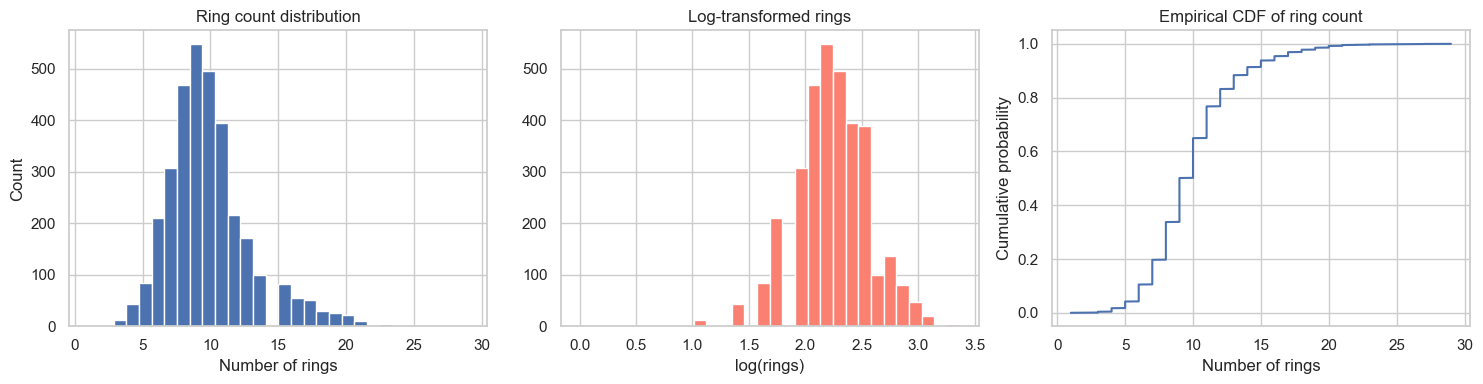

Min:      1
Max:      29
Mean:     9.94
Std:      3.21
Skewness: 1.113


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(y_train, bins=30, edgecolor="white")
axes[0].set_title("Ring count distribution")
axes[0].set_xlabel("Number of rings")
axes[0].set_ylabel("Count")

axes[1].hist(np.log(y_train), bins=30, edgecolor="white", color="salmon")
axes[1].set_title("Log-transformed rings")
axes[1].set_xlabel("log(rings)")

# Empirical CDF
sorted_y = np.sort(y_train)
cdf = np.arange(1, len(sorted_y) + 1) / len(sorted_y)
axes[2].plot(sorted_y, cdf)
axes[2].set_title("Empirical CDF of ring count")
axes[2].set_xlabel("Number of rings")
axes[2].set_ylabel("Cumulative probability")

plt.tight_layout()
plt.savefig("../reports/figures/abalone_target_distribution.pdf")
plt.show()

print(f"Min:      {y_train.min():.0f}")
print(f"Max:      {y_train.max():.0f}")
print(f"Mean:     {y_train.mean():.2f}")
print(f"Std:      {y_train.std():.2f}")
print(f"Skewness: {float(np.mean((y_train - y_train.mean())**3) / y_train.std()**3):.3f}")

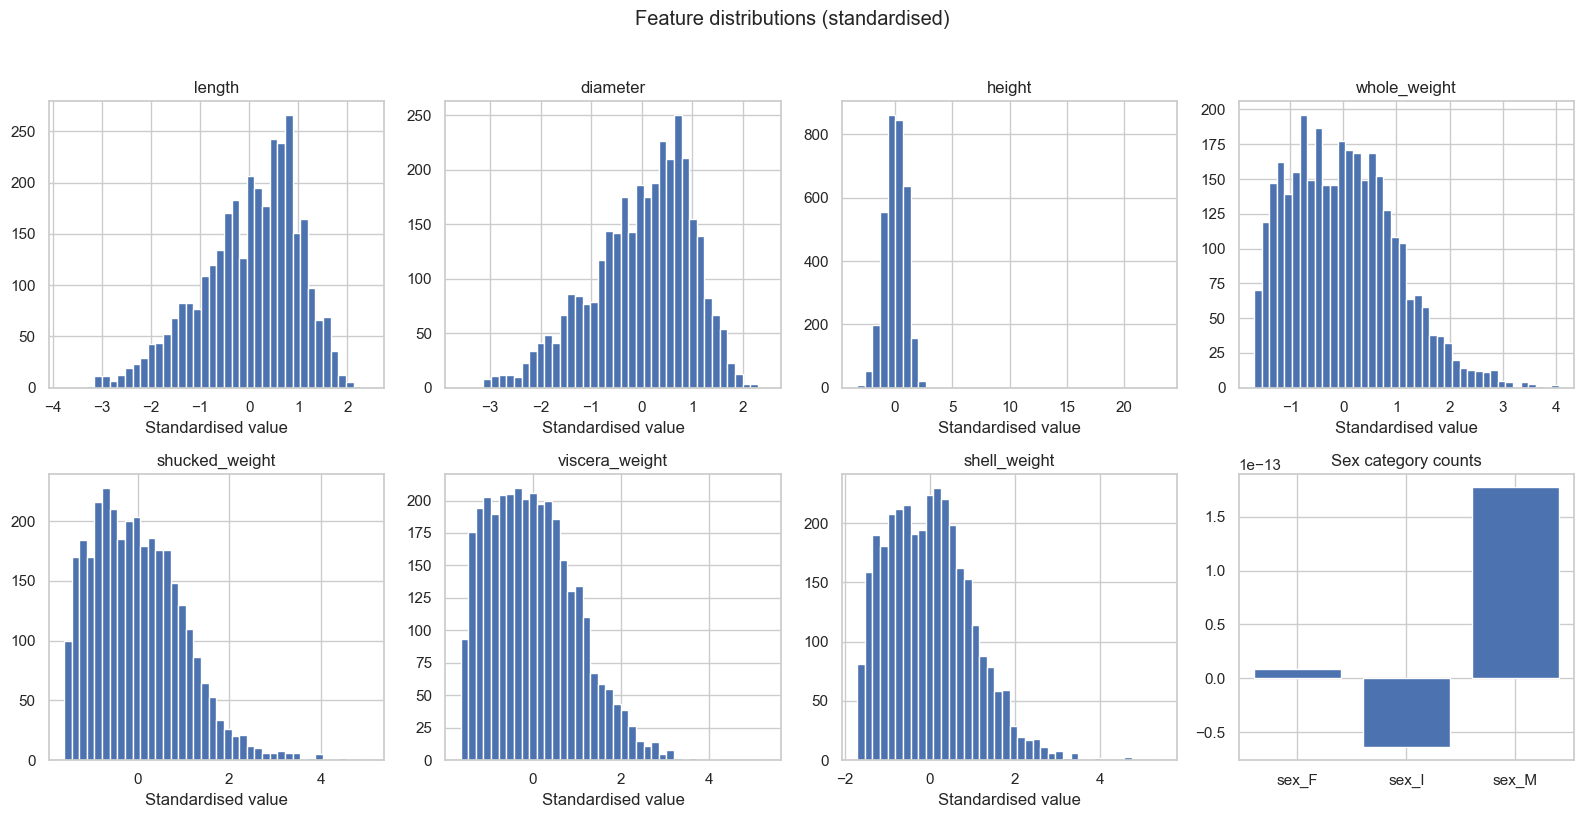

In [5]:
# Exclude sex dummies (last 3 features) for continuous plot
continuous_features = [f for f in feature_names if not f.startswith("sex_")]
continuous_idx = [feature_names.index(f) for f in continuous_features]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, (idx, name) in enumerate(zip(continuous_idx, continuous_features)):
    axes[i].hist(X_train[:, idx], bins=40, edgecolor="white")
    axes[i].set_title(name)
    axes[i].set_xlabel("Standardised value")

# Sex dummy counts in last panel
sex_cols = [f for f in feature_names if f.startswith("sex_")]
sex_idx = [feature_names.index(f) for f in sex_cols]
sex_counts = X_train[:, sex_idx].sum(axis=0)
axes[7].bar(sex_cols, sex_counts)
axes[7].set_title("Sex category counts")

plt.suptitle("Feature distributions (standardised)", y=1.02)
plt.tight_layout()
plt.savefig("../reports/figures/abalone_feature_distributions.pdf")
plt.show()

C:\Users\ramfe\AppData\Local\Temp\ipykernel_26028\2674877570.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(groups, labels=labels)


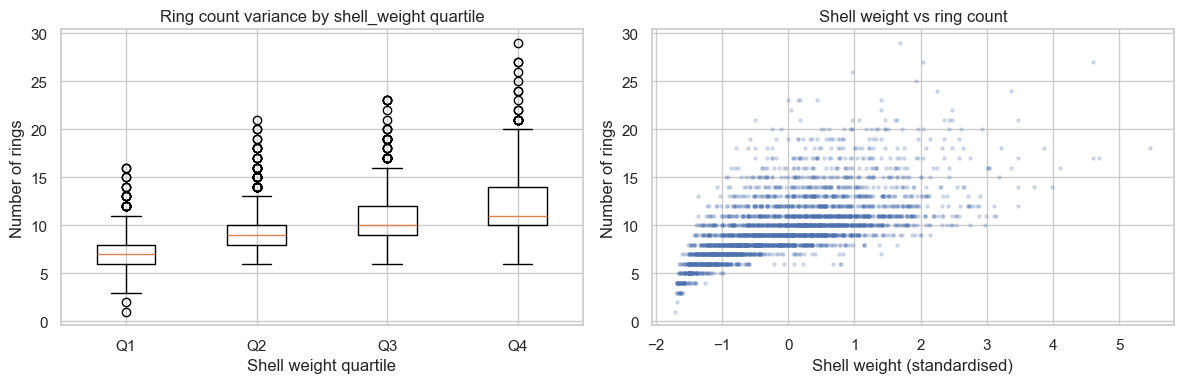

In [6]:
# Use shell_weight as the main predictor (highest correlation)
shell_idx = feature_names.index("shell_weight")
shell = X_train[:, shell_idx]

quartiles = np.percentile(shell, [0, 25, 50, 75, 100])
groups = []
labels = []
for i in range(4):
    mask = (shell >= quartiles[i]) & (shell < quartiles[i + 1])
    groups.append(y_train[mask])
    labels.append(f"Q{i+1}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(groups, labels=labels)
axes[0].set_title("Ring count variance by shell_weight quartile")
axes[0].set_xlabel("Shell weight quartile")
axes[0].set_ylabel("Number of rings")

axes[1].scatter(shell, y_train, alpha=0.2, s=5)
axes[1].set_title("Shell weight vs ring count")
axes[1].set_xlabel("Shell weight (standardised)")
axes[1].set_ylabel("Number of rings")

plt.tight_layout()
plt.savefig("../reports/figures/abalone_heteroscedasticity.pdf")
plt.show()

In [7]:
print("=== Key observations for distributional regression ===")
print()
print("1. TARGET: Ring count is right-skewed integer-valued data.")
print("   A Gaussian assumption will be approximate at best.")
print("   Consider Poisson or negative binomial families.")
print()
print("2. HETEROSCEDASTICITY: Variance of ring count increases")
print("   with shell weight — heavier abalone have more variable ages.")
print("   Point prediction will underestimate uncertainty for large abalone.")
print()
print("3. CORRELATIONS: Physical measurements are highly correlated")
print("   with each other (multicollinearity). Penalisation (L1/L2)")
print("   will be important for stable estimation.")

=== Key observations for distributional regression ===

1. TARGET: Ring count is right-skewed integer-valued data.
   A Gaussian assumption will be approximate at best.
   Consider Poisson or negative binomial families.

2. HETEROSCEDASTICITY: Variance of ring count increases
   with shell weight — heavier abalone have more variable ages.
   Point prediction will underestimate uncertainty for large abalone.

3. CORRELATIONS: Physical measurements are highly correlated
   with each other (multicollinearity). Penalisation (L1/L2)
   will be important for stable estimation.


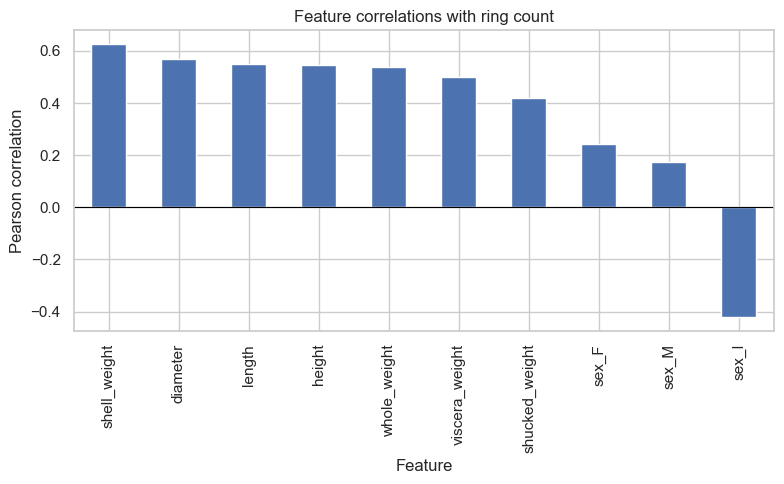

Top 3 correlated features:
shell_weight    0.626008
diameter        0.568907
length          0.551131


In [8]:
df = pd.DataFrame(X_train, columns=feature_names)
df["rings"] = y_train

correlations = df.corr()["rings"].drop("rings").sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
correlations.plot(kind="bar", ax=ax, edgecolor="white")
ax.set_title("Feature correlations with ring count")
ax.set_xlabel("Feature")
ax.set_ylabel("Pearson correlation")
ax.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig("../reports/figures/abalone_correlations.pdf")
plt.show()

print("Top 3 correlated features:")
print(correlations.head(3).to_string())